# Dynamical mean-field theory of the disordered ring

Derives and plots the DMFT description of the ring model: the effective gain G_Q(h), the
weight kernel J(Δθ), the stability of the bump and homogeneous solutions across (β, σ), and
mean-field integration of a real velocity signal. The entire notebook is deterministic; it
draws no random numbers.

**Produces** Figure 7 (`figures/dmft_theory.pdf`), assembled in the final cell.

**Reads** `data/jacobian_results.npz` and `data/dmft_simulation_results.npz`, plus
`data/hd_timeseries.npz` when regenerating them.

In [1]:
# Regeneration switches (default off so a normal run cannot overwrite committed figures/caches):
REGENERATE_CACHES = False
SAVE_FIGURES = False

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from ring import dmft, data_driven, style

## Effective nonlinearity (Fig 7, panel b)

Under DMFT the single-neuron nonlinearity is replaced by an effective gain G_Q(h) averaged over the quenched variance Q. Increasing Q smooths and shallows the gain, the mechanism by which disorder softens the network's effective nonlinearity.

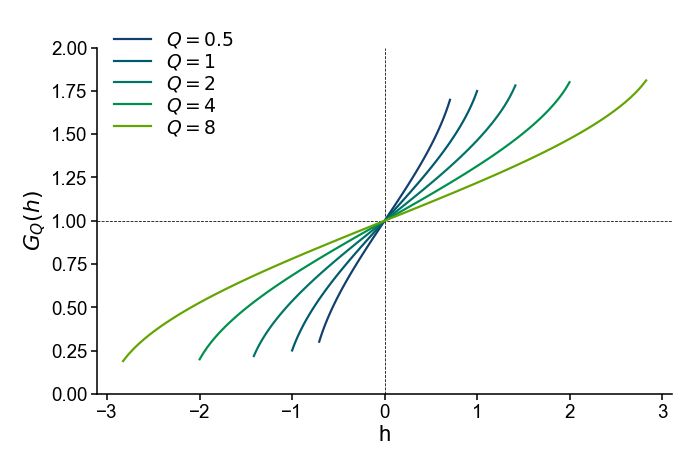

In [2]:
"""
Plot effective nonlin
"""

def plot_nonlin(ax):
    Q_values = [0.5, 1, 2, 4, 8]
    # Q takes 'ocean', deliberately UNLIKE panel A's 'ember': the two panels sweep
    # different parameters and should not read as one continuing series.
    colors = style.sweep_colors(len(Q_values), 'ocean')
    
    G = dmft.DMFTModel(scale=1.4211, g=2.7659).F
    G_Q = lambda Q, h: G(1., Q, h)
    
    for i, Q in enumerate(Q_values):
        h = np.linspace(-np.sqrt(Q), np.sqrt(Q), 100)
        y = G_Q(Q, h)
        color = colors[i]
        ax.plot(h, y, color=color, label=f'$Q={Q}$')
        
        # Add Q value at the upper-right endpoint
    ax.set_ylim(0, 2)
    
    ax.axhline(1, c='black', zorder=0, lw=0.25, ls='--')
    ax.axvline(0, c='black', zorder=0, lw=0.25, ls='--')
    
    ax.set_xlabel('h')
    ax.set_ylabel('${G}_Q(h)$')
    ax.legend(loc='upper left', labelspacing=0.1, bbox_to_anchor=[0,0,1,1.1])



fig, ax = plt.subplots(1, 1, figsize=(3.3, 2))
plot_nonlin(ax)
plt.show()


## Weight kernels (Fig 7, panel a)

The mean-field weight kernel J(Δθ) across inverse-temperature β and width σ. The Mexican-hat shape, local excitation with broad inhibition, emerges from the tuning-curve statistics rather than being imposed.

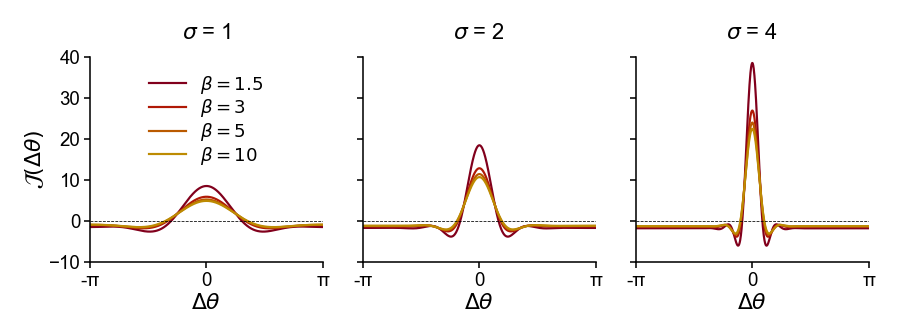

In [3]:
"""
Plot weights
"""

def plot_weights(axes):
    scales = [1, 2, 4]
    g_values = [1.5, 3, 5, 10]
    # beta takes the warm 'ember' ramp while Q in the panel below takes
    # 'ocean', keeping the two DMFT parameter families distinct.
    colors = style.sweep_colors(len(g_values), 'ember')
    
    x = np.linspace(-np.pi, np.pi, 1000)
    
    for i, scale in enumerate(scales):
        for j, g in enumerate(g_values):
            model = dmft.DMFTModel(N_theta=1000, g=g, scale=scale)
            axes[i].plot(x, np.roll(model.J, 500), color=colors[j], label=f'$\\beta={g}$')
        
        axes[i].set_title(f'$\\sigma$ = {scale}')
        axes[i].set_xlim(-np.pi, np.pi)
        axes[i].set_xticks([-np.pi, 0, np.pi])
        axes[i].set_xticklabels(["-π", "0", "π"])
        
        if i == 0:
            axes[i].set_ylabel('$\\mathcal{J}(\\Delta \\theta)$')
        axes[i].set_xlabel('$\\Delta \\theta$')
        axes[i].axhline(0, c='black', ls='--', lw=0.25)
        axes[i].set_ylim(-10, 40)
    
    legend = axes[0].legend(loc='upper center', fontsize='small', labelspacing=0.1)


fig, axes = plt.subplots(1, 3, figsize=(4, 1.5), sharex=True, sharey=True)
plot_weights(axes)
plt.tight_layout()
plt.show()

## Stability sweep (writes `data/jacobian_results.npz`)

Sweeps a 40 × 20 grid of (β, σ) and stores the leading eigenvalues of the Jacobian for both the bump and homogeneous solutions. `run_analysis()` only runs when `REGENERATE_CACHES = True`, so a normal run does not overwrite the cache you downloaded.

In [4]:
"""
Run stability analysis
"""

def run_analysis():
    """Run parameter sweep and save results"""
    g_vals = np.logspace(-2, 2, 40)
    scale_vals = np.logspace(0, 2, 20)
    n_g = len(g_vals)
    n_scale = len(scale_vals)

    N_theta = 500
    K = 5 #how many eigvals to save
    
    results = {
        'g_vals': g_vals,
        'scale_vals': scale_vals,
        'bump_eigenvals': np.zeros((n_g, n_scale, K))*1j,
        'homo_eigenvals': np.zeros((n_g, n_scale, K))*1j,
    }    
    
    for i in range(n_g):
        print(f"Processing g index {i}/{n_g}")
        for j in range(n_scale):
            g = g_vals[i]
            scale = scale_vals[j]
            model = dmft.DMFTModel(N_theta=N_theta, scale=scale, g=g)
            
            _, w_bump = model.compute_bump_jacobian()
            results['bump_eigenvals'][i, j, :] = w_bump[:K]
            
            _, w_homo = model.compute_homogeneous_jacobian()
            results['homo_eigenvals'][i, j, :] = w_homo[:K]
            
    # Save results
    np.savez('../data/jacobian_results.npz',
             g_vals=results['g_vals'],
             scale_vals=results['scale_vals'],
             bump_eigenvals=results['bump_eigenvals'],
             homo_eigenvals=results['homo_eigenvals'])



if REGENERATE_CACHES:
    run_analysis()


## Stability phase diagrams (Fig 7, panels d–e)

Both panels are plotted as −log₁₀ of the relevant eigenvalue, i.e. $\log_{10}$ of the characteristic timescale t\*/τ: panel d shows how fast the bump relaxes back, panel e how fast the homogeneous state runs away. The bump is stable and the homogeneous state unstable over a broad region of the plane.

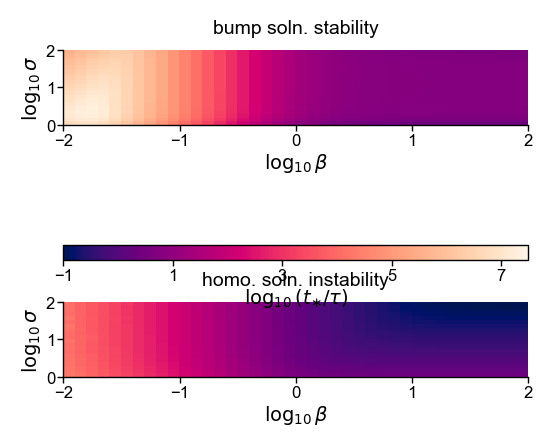

In [5]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

_stability_cbar_state = None

def plot_stability(ax, data, title, label, size="20%", pad=0.6, vmin=None, vmax=None,
                   ticks=None, add_colorbar=True):
    """Generic stability plot function.

    The final composite passes shared limits to panels D/E so one centered
    colorbar truthfully serves both maps. Standalone calls retain a local bar.
    """
    im = ax.imshow(data.T,
                   origin='lower',
                   extent=[np.log10(stability_results['g_vals'][0]), 
                          np.log10(stability_results['g_vals'][-1]),
                          np.log10(stability_results['scale_vals'][0]), 
                          np.log10(stability_results['scale_vals'][-1])], 
                   cmap=style.field_cmap('stability'),
                   vmin=vmin,
                   vmax=vmax)
    
    if add_colorbar:
        global _stability_cbar_state
        divider = make_axes_locatable(ax)
        spacer_cax = divider.append_axes("bottom", size=size, pad=pad)
        spacer_cax.set_visible(False)
        ax.figure.canvas.draw()
        spacer_pos = spacer_cax.get_position()
        if (_stability_cbar_state is None or
                _stability_cbar_state['fig'] is not ax.figure):
            bar_ax = ax.figure.add_axes(spacer_pos.bounds)
            cbar = ax.figure.colorbar(im, cax=bar_ax, orientation='horizontal',
                                      label=label, ticks=ticks)
            cbar.outline.set_linewidth(0.5)
            _stability_cbar_state = dict(fig=ax.figure, bar_ax=bar_ax,
                                         left_pos=spacer_pos)
        else:
            left_pos = _stability_cbar_state['left_pos']
            bar_ax = _stability_cbar_state['bar_ax']
            bar_x = 0.5 * (left_pos.x0 + spacer_pos.x1) - 0.5 * left_pos.width
            bar_ax.set_position([bar_x, left_pos.y0, left_pos.width,
                                 left_pos.height])
    
    ax.set_xlabel('$\\log_{10}\\beta$')
    ax.set_ylabel('$\\log_{10}\\sigma$')
    ax.set_title(title)
    ax.set_yticks([0,1,2])
    ax.set_xticks([-2, -1, 0, 1, 2])
    
    return im

def plot_bump_stability(ax, size="20%", pad=0.6, vmin=-1, vmax=7.5,
                        ticks=None, add_colorbar=True):
    data = -np.log10(-stability_results['bump_eigenvals'][..., 1].real)
    return plot_stability(ax, data, 'bump soln. stability', 
                         '$\\log_{10}(t_{\\ast}/\\tau)$',
                         size, pad, vmin=vmin, vmax=vmax,
                         ticks=[-1, 1, 3, 5, 7] if ticks is None else ticks,
                         add_colorbar=add_colorbar)

def plot_homo_stability(ax, size="20%", pad=0.6, vmin=-1, vmax=7.5,
                        ticks=None, add_colorbar=True):
    data = -np.log10(stability_results['homo_eigenvals'][..., 0].real)
    return plot_stability(ax, data, 'homo. soln. instability',
                         '$\\log_{10}(t_{\\ast}/\\tau)$',
                         size, pad, vmin=vmin, vmax=vmax,
                         ticks=[-1, 1, 3, 5, 7] if ticks is None else ticks,
                         add_colorbar=add_colorbar)

stability_results = np.load('../data/jacobian_results.npz')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 3), dpi=200)
plot_bump_stability(ax1)
plot_homo_stability(ax2)
plt.show()

## Velocity-driven simulation (writes `data/dmft_simulation_results.npz`)

Drives the mean-field model with the real ω(t) from the mouse HD recording, discards the first 20 s of transient, and saves m(θ, t) against the integrated target. `run_sim()` only runs when `REGENERATE_CACHES = True`, so a normal run does not overwrite the 72 MB cache.

In [6]:
from scipy.interpolate import interp1d


def run_sim():
    """Run simulation and save results"""
    # Simulation parameters
    N_theta = 1000
    scale = 1.4211
    g = 2.7659
    T = 110
    dt = 0.001
    T_eval = 0.01
    tau = 0.05
    
    # Define forcing function
    hd, omega, data_dt = data_driven.load_hd_and_omega() 
    omega_func = interp1d(np.arange(len(omega))*data_dt, omega)
    
    # Run simulation
    model = dmft.DMFTModel(N_theta=N_theta, scale=scale, g=g)
    t, m, m_hat, g_dyn = model.simulate(
        T=T, 
        dt=dt, 
        T_eval=T_eval, 
        omega_func=omega_func, 
        tau=tau
    )
    
    # Compute target head direction
    target_hd = np.mod(np.cumsum(omega_func(t))*(t[1]-t[0]), 2*np.pi)

    to_save = t >= 20.
    
    # Save results
    np.savez('../data/dmft_simulation_results.npz',
             t=t[to_save]-20.,
             m=m[to_save],
             target_hd=target_hd[to_save],
             params=dict(N_theta=N_theta, scale=scale, g=g, 
                        T=T, dt=dt, T_eval=T_eval, tau=tau))

if REGENERATE_CACHES:
    run_sim()



## The mean-field network integrates real head-direction velocity (Fig 7, panel c)

The red target-HD overlay is the integral of the mouse's measured angular velocity; the mean-field bump tracks it. `remove_discontinuities_mod_2pi` is applied on load, mirroring `data_driven_attractor.ipynb`.

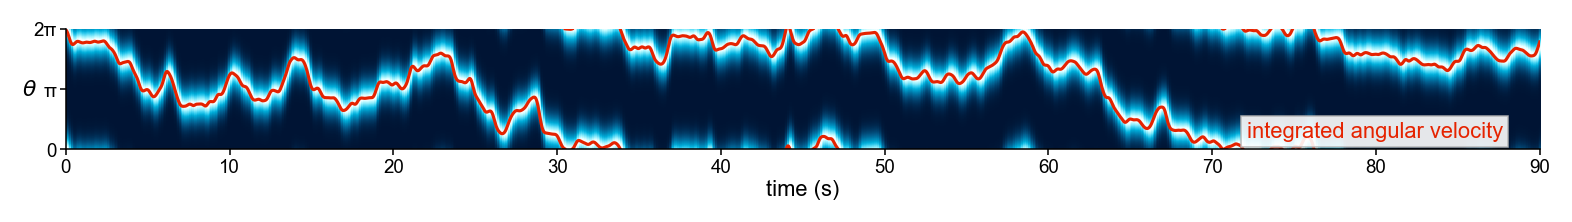

In [7]:
"""
Plot sim output
"""

from ring import data_driven

def plot_simulation(ax):
    """Load and plot simulation results"""
    # Load data
    data = np.load('../data/dmft_simulation_results.npz')
    t = data['t']
    m = data['m']
    target_hd = data['target_hd']
    dt = t[1]-t[0]
    target_hd = data_driven.remove_discontinuities_mod_2pi(target_hd)
    data_driven.plot_head_direction(ax=ax, m=m[::10], hd=target_hd, m_dt=dt*10, hd_dt=dt, vmin=1)
    ax.set_xticks(np.arange(10)*10)
    # Label the red integrated-angular-velocity overlay, tucked in the
    # bottom-right corner on a near-opaque white chip so it stays readable.
    ax.text(0.975, 0.06, "integrated angular velocity", color=style.HD_COLOR, size=7,
            transform=ax.transAxes, ha='right', va='bottom',
            bbox=dict(boxstyle='square,pad=0.25', facecolor='white',
                      alpha=0.9, edgecolor='0.7', linewidth=0.5))

fig, ax = plt.subplots(figsize=(7, 1))
plot_simulation(ax)
plt.tight_layout()
plt.show()


## Role of Q in bump stability (Fig 7, panel f)

Recomputes the bump Jacobian spectrum with the Q-dependence of the effective gain suppressed (`exclude_Q=True`). Without it, eigenvalues cross zero, showing that the quenched-variance feedback, not the weight kernel alone, is what stabilizes the bump.

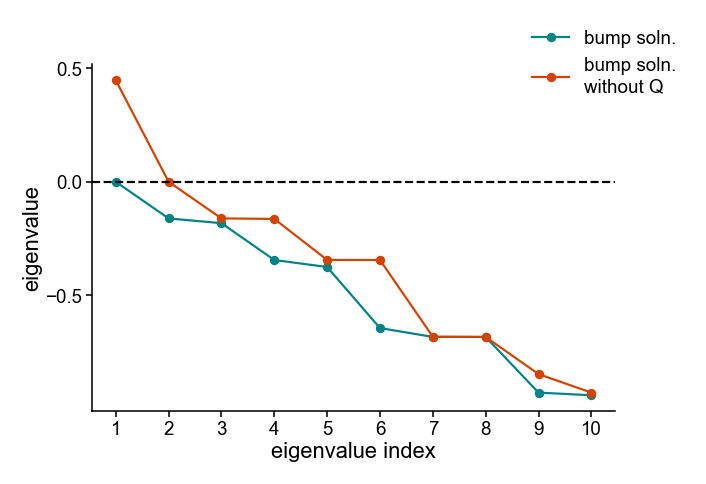

In [8]:

def plot_exclude_Q_spectra(ax):
    model = dmft.DMFTModel(N_theta=500, scale=1.4211, g=2.7659)
    _, w1 = model.compute_bump_jacobian()
    jac2, w2 = model.compute_bump_jacobian(exclude_Q=True)
    
    ax.plot(np.arange(10)+1, w1.real[:10], marker='o', mew=0, ms=3, color=style.LINE_A, label='bump soln.')
    ax.plot(np.arange(10)+1, w2.real[:10], marker='o', mew=0, ms=3, color=style.LINE_B, label='bump soln.\nwithout Q')
    ax.axhline(0, c='black', ls='--')
    ax.legend(bbox_to_anchor=[0,0,1.15,1.15])
    ax.set_xlabel("eigenvalue index")
    ax.set_xticks([1,2,3,4,5,6,7,8,9,10])
    ax.set_ylabel("eigenvalue")
    ax.set_yticks([-0.5, 0, 0.5])

fig, ax = plt.subplots(1, 1, figsize=(3, 2))
plot_exclude_Q_spectra(ax)

## Assemble Figure 7

Lays out the six panels and writes `../figures/dmft_theory.pdf`. The `plt.savefig` only runs when `SAVE_FIGURES = True`.

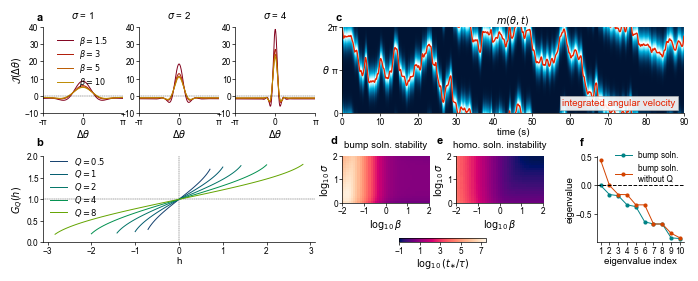

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create figure at the full paper width but 80% of its former height. The shorter
# canvas removes unnecessary vertical stretch while preserving the panel layout.
fig = plt.figure(figsize=(style.FULL_W, 2.8), dpi=100)

# Create main GridSpec
gs = gridspec.GridSpec(2, 5, height_ratios=[1, 1], width_ratios=[1.25, 0.4, 0.4, 0, 0.4],
                       left=0.055, right=1-0.055, hspace=0.5, wspace=0.25)

# Create nested GridSpec for the Weights section
gs_weights = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[0, 0])

# Create all subplots
ax1_1 = plt.subplot(gs_weights[0, 0])  # First third of Weights
ax1_2 = plt.subplot(gs_weights[0, 1])  # Second third of Weights
ax1_3 = plt.subplot(gs_weights[0, 2])  # Last third of Weights

ax2 = plt.subplot(gs[1, 1])    # Evals 1
ax3 = plt.subplot(gs[1, 2])    # Evals 2
ax4 = plt.subplot(gs[1, 4])    # Exclude Q spectra
ax5 = plt.subplot(gs[1, 0])    # nonlin
ax6 = plt.subplot(gs[0, 1:])   # Velocity drive

plot_weights([ax1_1, ax1_2, ax1_3])
plot_nonlin(ax5)
plot_bump_stability(ax2, pad=0.35, size="10%")
plot_homo_stability(ax3, pad=0.35, size="10%")
plot_exclude_Q_spectra(ax4)
plot_simulation(ax6)
ax6.set_title(r'$m(\theta, t)$', pad=2)

ax1_1.text(0, 1.05, s="a", weight="bold", size=8, va="bottom", ha="right", transform=ax1_1.transAxes)
ax5.text(0, 1.1, s="b", weight="bold", size=8, va="bottom", ha="right", transform=ax5.transAxes)
ax6.text(0, 1.05, s="c", weight="bold", size=8, va="bottom", ha="right", transform=ax6.transAxes)

ax2.text(-0.05, 1.22, s="d", weight="bold", size=8, va="bottom", ha="right", transform=ax2.transAxes)
ax3.text(-0.15, 1.22, s="e", weight="bold", size=8, va="bottom", ha="right", transform=ax3.transAxes)
ax4.text(-0.15, 1.1, s="f", weight="bold", size=8, va="bottom", ha="right", transform=ax4.transAxes)


if SAVE_FIGURES:
    plt.savefig("../figures/dmft_theory.pdf", dpi=400)
plt.show()